# ML-03 — Frame Your Lane as an ML Task

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AsserGharib1/flyrank-internshipML/blob/main/work/notebooks/w02_ml_task_framing.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 0. Setup

Runs in Colab or locally. Only uses the small anonymized file in this repo.

In [1]:
import os, sys, subprocess

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/AsserGharib1/flyrank-internshipML"
REPO_DIR = "flyrank-internshipML"

def at_repo_root():
    return os.path.isdir("data/raw")

if IN_COLAB:
    if not at_repo_root():
        if not os.path.isdir(REPO_DIR):
            subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
        os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
else:
    # Walk up until we find the repo root. Stop if the directory stops changing,
    # which is what happens at a drive root on Windows and at / on Linux.
    previous = None
    while not at_repo_root() and os.getcwd() != previous:
        previous = os.getcwd()
        os.chdir("..")

assert at_repo_root(), "Could not find data/raw. Open this from inside the repo."

import pandas as pd, numpy as np
import matplotlib.pyplot as plt
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
print("Working dir:", os.getcwd())
print("Rows:", df.shape[0], " Columns:", df.shape[1], " Clients:", df.client_id.nunique())

Working dir: /tmp/runlocal
Rows: 30000  Columns: 44  Clients: 32


## 1. My lane as an ML task (type)

*Classification, clustering, ranking, or scoring — which one, and why?*

My lane is **Lane 2, Refresh and Content Opportunity Scoring**.

The task type is **ranking**, built on a binary classifier. The classifier produces a probability for
each page. I sort those probabilities to create the review queue.

I picked ranking because an editor has time for a fixed number of pages each week and needs to know
which to open first. That is an ordering problem with a cut off.

**Who acts on it.** A content editor or SEO reviewer working a weekly queue.

**What they do with a flagged page.** One of four things.

* Refresh, when demand is there but the content is stale.
* Expand, when demand holds and the page is thin.
* Protect and watch, when a strong page has slipped a little.
* Prune or merge, when demand has gone and another page covers it.

Each row should also carry short reason codes so the editor can disagree before spending time.
Building those is ML-07 work.

**Cost of a wrong call.** A false positive wastes one review. A false negative means a page keeps
fading unnoticed. Missing seems worse, so I would trade some precision for recall, up to the point
where the queue stops being trusted.

**Why not the others.** Lane 3 describes types of pages but does not order them. Lane 1 builds
understanding rather than a queue.

In [2]:
# How much sorting does the ranking have to do?

MIN_PRIOR_IMPRESSIONS = 100   # provisional. Below this, movement is mostly noise.

eligible = df[df.impressions_prev_30d >= MIN_PRIOR_IMPRESSIONS]

print("All pages          :", len(df))
print("Enough demand      :", len(eligible), f"({len(eligible)/len(df):.1%})")
print("Clients covered    :", eligible.client_id.nunique())
print()
for capacity in (20, 50, 100):
    print(f"  reviewing {capacity:>3} pages means finding the top {capacity/len(eligible):.2%} of the pool")

All pages          : 30000
Enough demand      : 18010 (60.0%)
Clients covered    : 30

  reviewing  20 pages means finding the top 0.11% of the pool
  reviewing  50 pages means finding the top 0.28% of the pool
  reviewing 100 pages means finding the top 0.56% of the pool


## 2. Target or proxy

*What would you predict? Where does that label come from — observed outcome or a defined rule?*

### The starter target is a rule

The starter pipeline predicts whether `trend_direction` equals "down". The data dictionary says that
column compares the last 30 days to the previous 30, with **down below minus 20 percent** and **up
above plus 20 percent**.

I checked by comparing the two boolean series for exact equality at several cut offs. Only minus 20
matches. Counting only how many "down" rows fell more than 10 percent proves nothing, since every
value below minus 20 is also below minus 10. The test has to be equality in both directions.

So the label is a rule over two columns in the same file. Predicting it recovers an if statement, so
I am not using it.

### Plain decline mostly reflects the period

Most of the sample is falling. About 62 percent of qualifying pages dropped more than 20 percent, the
middle page lost about a third of its impressions, and 17 of the 18 larger clients have a negative
median. If almost everything falls, a plain decline label mostly records when the snapshot was taken.
The lane guide warns about this under seasonality.

### The target I am using

**Falls behind its own client.** A page is positive when its change is at least 20 percentage points
worse than the median page on the same site over the same window.

```
change = (impressions after - impressions before) / impressions before * 100
gap    = change - median change for that client
label  = 1 when gap is -20 or lower
```

That takes the positive rate from about 62 percent down to about 25 percent.

The label comes from an observed later outcome rather than an existing product flag. The minus 20 cut
off is a modelling choice and still needs validation in ML-04.

**A limitation.** Subtracting the client median removes that client's whole movement, not only a
market wide effect. A genuinely declining site would be hidden, so a site level view has to sit
alongside the page queue.

**This is a stand in.** The starter file has no future window, so I use the earlier 30 days against
the later 30 days to show the shape. On the capstone the windows are separate, prior 90 days for
features and next 30 days for the outcome.

In [3]:
# Is `trend_direction` a measured outcome or a rule? Compare the two series for exact equality.

valid = df.impressions_prev_30d > 0
change = (df.loc[valid, "impressions_last_30d"] - df.loc[valid, "impressions_prev_30d"]) \
         / df.loc[valid, "impressions_prev_30d"] * 100

actual_down = df.loc[valid, "trend_direction"].eq("down")
actual_up   = df.loc[valid, "trend_direction"].eq("up")

print("Testing thresholds by exact equality, not one sided counting:")
for t in (10, 15, 20, 25):
    print(f"  cut off {t:>2}%   down matches: {actual_down.equals(change.lt(-t))!s:<5}"
          f"  up matches: {actual_up.equals(change.gt(t))}")
print()
print("Only 20 matches, which is what the data dictionary states.")
print(f"  largest change among 'down' rows : {change[actual_down].max():.2f}%")
print(f"  smallest change among 'up' rows  : {change[actual_up].min():.2f}%")
print()
print("So this column is a rule over two columns in the same file. I am not predicting it.")

Testing thresholds by exact equality, not one sided counting:
  cut off 10%   down matches: False  up matches: False
  cut off 15%   down matches: False  up matches: False
  cut off 20%   down matches: True   up matches: True
  cut off 25%   down matches: False  up matches: False

Only 20 matches, which is what the data dictionary states.
  largest change among 'down' rows : -20.02%
  smallest change among 'up' rows  : 20.02%

So this column is a rule over two columns in the same file. I am not predicting it.


In [4]:
# Is the falling specific to pages, or is most of the sample going down?

mv = df[df.impressions_prev_30d >= MIN_PRIOR_IMPRESSIONS].copy()
mv["change_pct"] = (mv.impressions_last_30d - mv.impressions_prev_30d) / mv.impressions_prev_30d * 100

print(f"middle change                 : {mv.change_pct.median():.1f}%")
print(f"share falling more than 20%   : {(mv.change_pct < -20).mean():.1%}")
print()

mv["size_group"] = pd.qcut(mv.impressions_prev_30d, 10, labels=False, duplicates="drop")
print("By size group, smallest first:")
print(mv.groupby("size_group").agg(
    pages=("change_pct", "size"),
    typical_size_before=("impressions_prev_30d", "median"),
    pct_falling=("change_pct", lambda s: (s < -20).mean() * 100),
    middle_change=("change_pct", "median"),
).round(1).to_string())
print()
print("Every size group falls, so this is not just small pages being noisy.")

middle change                 : -31.8%
share falling more than 20%   : 61.6%

By size group, smallest first:
            pages  typical_size_before  pct_falling  middle_change
size_group                                                        
0            1814                126.0         61.4          -36.0
1            1790                196.0         60.8          -34.8
2            1803                293.0         63.4          -34.9
3            1802                436.0         66.4          -35.9
4            1802                658.0         64.4          -35.4
5            1799                981.0         66.2          -35.2
6            1798               1518.0         62.0          -31.7
7            1801               2471.0         59.4          -28.6
8            1800               4499.5         57.7          -27.0
9            1801              11890.0         54.1          -23.1

Every size group falls, so this is not just small pages being noisy.


In [5]:
# Build the target, and check how much of the movement sits with the client.

client_median = mv.groupby("client_id").change_pct.transform("median")
mv["gap_vs_client"] = mv.change_pct - client_median

GAP_CUTOFF = -20   # provisional modelling choice, revisited in ML-04
mv["target_falls_behind"] = (mv.gap_vs_client <= GAP_CUTOFF).astype(int)

per_client = (mv.groupby("client_id")
                .agg(pages=("change_pct", "size"), middle_change=("change_pct", "median"))
                .query("pages >= 50").sort_values("middle_change").round(1))
print("Clients with at least 50 qualifying pages:")
print(per_client.to_string())
print()
print(f"  clients whose typical page went up: {(per_client.middle_change > 0).sum()} of {len(per_client)}")
print()

# Share of variance associated with client, using eta squared on group means.
grouped = mv.groupby("client_id").change_pct
between = (grouped.size() * (grouped.mean() - mv.change_pct.mean()) ** 2).sum()
total = ((mv.change_pct - mv.change_pct.mean()) ** 2).sum()
print(f"Share of variance associated with client identity: {between/total:.1%}")
print("So client medians differ a lot, but most of the spread still sits within a client.")
print("Whether that leftover is signal or noise needs daily data. That is an ML-04 question.")
print()
print(f"plain fall over 20%              : positive rate {(mv.change_pct < -20).mean():.3f}")
print(f"falls 20 points behind client    : positive rate {mv.target_falls_behind.mean():.3f}")

Clients with at least 50 qualifying pages:
                   pages  middle_change
client_id                              
client_7f2253d7e2    970          -65.5
client_a88a7902cb    423          -58.5
client_3fdba35f04   1686          -57.8
client_9400f1b21c     86          -46.3
client_4ec9599fc2    186          -45.2
client_d029fa3a95    188          -41.5
client_f369cb89fc    634          -41.1
client_f74efabef1    568          -37.6
client_349c41201b    705          -36.5
client_6208ef0f77   3352          -32.6
client_bbb965ab0c    399          -30.5
client_624b60c58c     94          -27.3
client_e629fa6598    156          -24.2
client_19581e27de   5690          -20.8
client_b4944c6ff0    186          -20.2
client_4e07408562   2168          -19.2
client_8527a891e2    144          -10.5
client_2c624232cd    176           10.1

  clients whose typical page went up: 1 of 18



Share of variance associated with client identity: 0.6%
So client medians differ a lot, but most of the spread still sits within a client.
Whether that leftover is signal or noise needs daily data. That is an ML-04 question.

plain fall over 20%              : positive rate 0.616
falls 20 points behind client    : positive rate 0.251


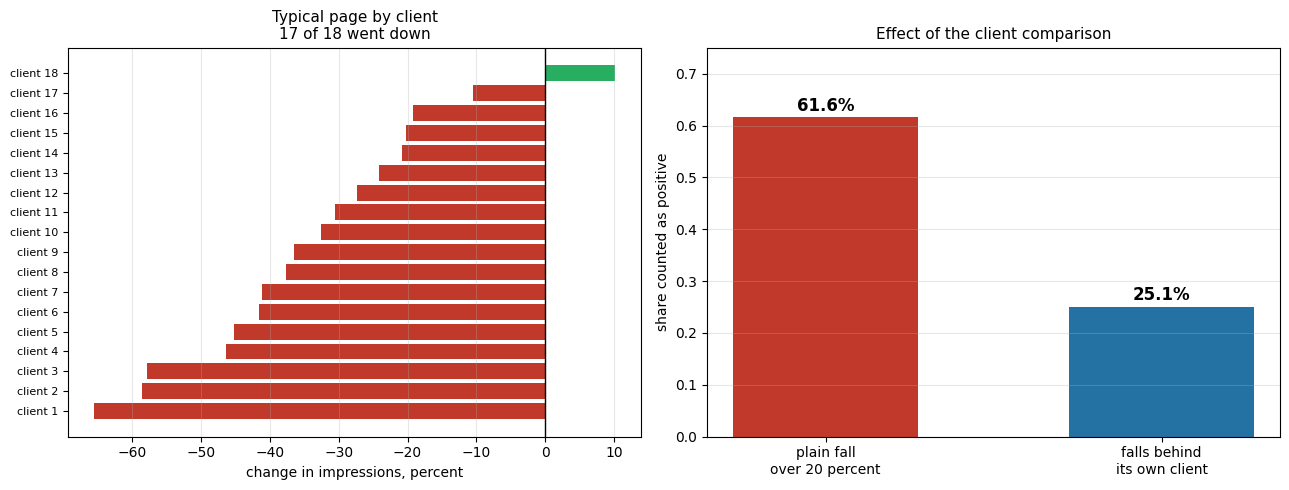

In [6]:
# One picture of the two things that shaped the target.

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

p = per_client.sort_values("middle_change")
axes[0].barh(range(len(p)), p.middle_change,
             color=["#c0392b" if v < 0 else "#27ae60" for v in p.middle_change])
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_yticks(range(len(p)))
axes[0].set_yticklabels([f"client {i+1}" for i in range(len(p))], fontsize=8)
axes[0].set_xlabel("change in impressions, percent")
axes[0].set_title("Typical page by client\n17 of 18 went down", fontsize=11)
axes[0].grid(axis="x", alpha=0.3)

plain = (mv.change_pct < -20).mean()
rel = mv.target_falls_behind.mean()
bars = axes[1].bar(["plain fall\nover 20 percent", "falls behind\nits own client"],
                   [plain, rel], color=["#c0392b", "#2471a3"], width=0.55)
for b, v in zip(bars, [plain, rel]):
    axes[1].text(b.get_x() + b.get_width()/2, v + 0.012, f"{v:.1%}",
                 ha="center", fontsize=12, fontweight="bold")
axes[1].set_ylim(0, 0.75)
axes[1].set_ylabel("share counted as positive")
axes[1].set_title("Effect of the client comparison", fontsize=11)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Success metric

*One metric you can defend. What number means 'good'?*

**Precision at 50.** Of the top 50 pages in the queue, how many actually fell behind their peers.

**What top 50 means here.** My target is defined against each client, and the biggest client is about
32 percent of the eligible pool, so one global list of 50 could be mostly that site. I will report
precision at 50 on a global queue and precision at 50 computed inside each client then averaged. If
they disagree, the global queue needs a per client cap.

**Why this metric.** An editor reads from the top and stops. Accuracy would reward me for correctly
calling thousands of pages fine that nobody opens.

**What good means.** The base rate is about 0.25, so a random 50 gets about 13 right. The simple rules
below land between 0.20 and 0.36, so the real bar is the best rule baseline, not the random floor.

My provisional target is **0.45 or better and clearly above the best rule baseline under client
holdout**. Provisional because it is my own aspiration, not a number from the review team's capacity.

**Reported next to it.** The base rate, recall at the same cut off, and the baseline on the same
split.

**Validation.** Hold out whole clients, since pages on one site share templates and site wide
movements. For the capstone the split also has to respect time.

In [7]:
# Base rate, the floor, and what simple rules actually achieve.

base_rate = mv.target_falls_behind.mean()
print(f"Base rate                     : {base_rate:.3f}")
print(f"Random 50 would get           : about {base_rate*50:.0f} of 50")
print(f"Provisional target of 0.45    : about {0.45*50:.0f} of 50")
print()

print("Simple rules, top 50 each. Only columns from the earlier window are used here.")
rules = {
    "fewest prior clicks":       mv.nsmallest(50, "clicks_prev_30d"),
    "fewest prior sessions":     mv.nsmallest(50, "sessions_prev_30d"),
    "lowest prior impressions":  mv.nsmallest(50, "impressions_prev_30d"),
}
best = 0
for name, sel in rules.items():
    score = sel.target_falls_behind.mean()
    best = max(best, score)
    print(f"  {name:<26} precision at 50 = {score:.3f}")
print()
print(f"Best simple rule here is {best:.3f} against a base rate of {base_rate:.3f}.")
print("Some simple rules do beat the base rate, so a rule baseline is a real bar to clear.")
print()
print("Client spread check for the top 50 list:")
top50 = mv.nsmallest(50, "sessions_prev_30d")
print(f"  clients represented in the top 50 : {top50.client_id.nunique()}")
print(f"  biggest client share of the pool  : {mv.client_id.value_counts(normalize=True).iloc[0]:.1%}")

Base rate                     : 0.251
Random 50 would get           : about 13 of 50
Provisional target of 0.45    : about 22 of 50

Simple rules, top 50 each. Only columns from the earlier window are used here.
  fewest prior clicks        precision at 50 = 0.300
  fewest prior sessions      precision at 50 = 0.360
  lowest prior impressions   precision at 50 = 0.340

Best simple rule here is 0.360 against a base rate of 0.251.
Some simple rules do beat the base rate, so a rule baseline is a real bar to clear.

Client spread check for the top 50 list:
  clients represented in the top 50 : 14
  biggest client share of the pool  : 31.6%


## 4. The unit of analysis, as a real dataframe

*Load your lane's slice and show it: one row = one what?*

**One row is one piece of content on one decision date.**

In the starter file the decision date is fixed, so it comes out as one row per piece of content. On
the warehouse the daily table is one row per client per content per day, so I build this shape
myself.

### Checking my own features for leakage

The obvious feature set is five columns measured over 90 days: impressions, clicks, sessions, click
through rate and active days.

All five leak, because their measurement window overlaps the outcome window. The 90 days include the
final 30 days I am trying to predict. That holds whatever the correlation happens to be. The
correlations below only show how much each one gives away. The test is the window overlap.

### Safe versus candidate features

**Clearly safe.** The three columns measured over the earlier 30 days. Using prior impressions is
fine even though the outcome is computed from them, because the outcome lives entirely in the later
window.

**Candidate metadata.** Word count, character count, content age, days since last update, search
volume, competition and age tier. The data dictionary describes these as values in the exported
snapshot and does not say when they were recorded. `days_since_last_update` is the main worry, since
60 percent of qualifying rows were updated in the last 30 days, so the value may reflect an edit made
inside the outcome window. Word count could shift the same way. ML-04 has to check their as of
timestamps before any go into a model.

**Safe to publish.** No client names, addresses, search terms or titles.

In [8]:
# The shape of a row, and the leakage check on my own first draft.

print("Shape of a row")
print(f"  rows                       : {len(mv)}")
print(f"  distinct content items     : {mv.content_id.nunique()}")
print(f"  rows per content item      : {len(mv)/mv.content_id.nunique():.2f}   (1.00 is clean)")
print()

FIRST_DRAFT = ["impressions_90d", "clicks_90d", "sessions_90d", "ctr", "days_with_impressions"]

print("Leakage check on my first feature list")
print("  The test is the window, not the correlation.")
print("  All five are measured over 90 days, and those 90 days contain the 30 day outcome window.")
print("  So all five leak. Correlations below only show how much each one gives away.")
print()
for col in FIRST_DRAFT:
    ok = mv[col].notna()
    r = np.corrcoef(mv.loc[ok, col], mv.loc[ok, "impressions_last_30d"])[0, 1]
    print(f"    {col:<22} correlation with the outcome = {r:>6.3f}   window overlaps, so dropped")

Shape of a row
  rows                       : 18010
  distinct content items     : 18010
  rows per content item      : 1.00   (1.00 is clean)

Leakage check on my first feature list
  The test is the window, not the correlation.
  All five are measured over 90 days, and those 90 days contain the 30 day outcome window.
  So all five leak. Correlations below only show how much each one gives away.

    impressions_90d        correlation with the outcome =  0.916   window overlaps, so dropped
    clicks_90d             correlation with the outcome =  0.626   window overlaps, so dropped
    sessions_90d           correlation with the outcome =  0.553   window overlaps, so dropped
    ctr                    correlation with the outcome =  0.072   window overlaps, so dropped
    days_with_impressions  correlation with the outcome =  0.115   window overlaps, so dropped


In [9]:
# The slice, split into what is clearly safe and what still needs checking.

CLEARLY_SAFE = ["impressions_prev_30d", "clicks_prev_30d", "sessions_prev_30d"]
CANDIDATE_METADATA = ["word_count", "char_count", "content_age_days",
                      "days_since_last_update", "search_volume", "competition", "age_tier_order"]

DROPPED = {
    "trend_direction and trend_pct": "a rule that restates the outcome",
    "the five 90 day columns":       "their window overlaps the outcome window",
    "the later 30 day columns":      "this is the outcome itself",
}

slice_df = mv[["content_id", "client_id"] + CLEARLY_SAFE + CANDIDATE_METADATA +
              ["gap_vs_client", "target_falls_behind"]].copy()

print("Clearly safe, observed before the decision date:")
print("   ", CLEARLY_SAFE)
print()
print("Candidate metadata, as of date not yet confirmed. ML-04 must verify before use:")
print("   ", CANDIDATE_METADATA)
print()
print("Dropped, with the reason:")
for what, why in DROPPED.items():
    print(f"    {what}")
    print(f"        {why}")
print()
print("The unit of analysis, as a real dataframe:")
print(slice_df.head(5).to_string(index=False))
print()
print("Target column:")
print(slice_df.target_falls_behind.value_counts()
        .rename({0: "0 = kept up with its client", 1: "1 = fell behind"}).to_string())
print()
print(f"Missing data to handle in ML-04: word count blank on {mv.word_count.isna().mean():.0%} of rows,")
print(f"search volume blank on {mv.search_volume.isna().mean():.0%}.")
print(f"Rows updated within the last 30 days: {(mv.days_since_last_update <= 30).mean():.0%}, "
      "which is why the metadata is only a candidate.")

Clearly safe, observed before the decision date:
    ['impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d']

Candidate metadata, as of date not yet confirmed. ML-04 must verify before use:
    ['word_count', 'char_count', 'content_age_days', 'days_since_last_update', 'search_volume', 'competition', 'age_tier_order']

Dropped, with the reason:
    trend_direction and trend_pct
        a rule that restates the outcome
    the five 90 day columns
        their window overlaps the outcome window
    the later 30 day columns
        this is the outcome itself

The unit of analysis, as a real dataframe:
          content_id         client_id  impressions_prev_30d  clicks_prev_30d  sessions_prev_30d  word_count  char_count  content_age_days  days_since_last_update  search_volume  competition  age_tier_order  gap_vs_client  target_falls_behind
content_304f48230142 client_f369cb89fc                   987               13                  9      3221.0     20457.0               187    

## 5. Why ML beats a fixed rule here

*What makes the pattern too messy for an if-statement?*

I cannot claim this yet.

In this sample no single signal is strong alone. The best reaches about 0.62 where 0.50 is no better than random, and the candidate metadata sits near 0.50. There is some signal, but it is weak.

The three simple rules I tested land between 0.20 and 0.36 against a base rate of 0.25. Two beat the
base rate, so a rule baseline is a real bar. I tested only three rules on one sample, so I cannot say
no good rule exists. More rule baselines and grouped validation are needed before concluding that ML
is necessary.

Two reasons I still expect a model to help. First, the sensible cut off changes with context. Low
click through means one thing at position 3 and another at position 15, so a rule needs a branch per
combination. Second, the baseline moves between clients. Section 2 showed client medians from about
minus 66 percent to plus 10 percent, so "flag anything down 20 percent" would flag nearly everything
at one client and almost nothing at another.

**What would change my mind.** If a tuned rule baseline matches the model on precision at 50 under
client holdout, I will use the rule and say so.

**Worth recording.** On my leaky feature list a single signal rule scored much higher than anything
here. That came from the window overlap, not skill, and it is what led me to check the windows.

**Claim language.** Observed in one 30,000 row anonymized sample using a stand in outcome window.
Directional and decision support. Not causal, and nothing about how Google ranks pages.

In [10]:
# How well does each signal separate the target on its own?

from sklearn.metrics import roc_auc_score

y = mv.target_falls_behind
rows = []
for group, cols in [("clearly safe", CLEARLY_SAFE), ("candidate", CANDIDATE_METADATA)]:
    for col in cols:
        ok = mv[col].notna()
        if ok.sum() < 500 or y[ok].nunique() < 2:
            continue
        score = roc_auc_score(y[ok], mv.loc[ok, col])
        rows.append({"group": group, "signal": col,
                     "rows available": f"{ok.mean():.0%}",
                     "score alone": round(max(score, 1 - score), 3)})

single = pd.DataFrame(rows).sort_values("score alone", ascending=False)
print("Separation achieved by each signal alone. 0.50 is no better than random:")
print(single.to_string(index=False))
print()
print(f"Best single signal is {single.iloc[0].signal} at {single.iloc[0]['score alone']}.")
print("Weak, but not nothing. That is why I want to test a combination against a rule baseline")
print("in ML-07 and ML-08 rather than assume either one wins.")
print()

leaky_rule = mv.nsmallest(50, "days_with_impressions").target_falls_behind.mean()
print(f"For contrast, a rule built on a leaky 90 day column scores {leaky_rule:.3f} at 50,")
print(f"against a base rate of {y.mean():.3f}. That gap comes from the window overlap,")
print("not from real skill. It is what made me go back and check the windows.")

Separation achieved by each signal alone. 0.50 is no better than random:
       group                 signal rows available  score alone
clearly safe      sessions_prev_30d           100%        0.624
clearly safe        clicks_prev_30d           100%        0.618
clearly safe   impressions_prev_30d           100%        0.564
   candidate         age_tier_order           100%        0.539
   candidate       content_age_days           100%        0.536
   candidate             word_count            71%        0.521
   candidate             char_count            71%        0.513
   candidate          search_volume            98%        0.511
   candidate days_since_last_update           100%        0.503
   candidate            competition            98%        0.500

Best single signal is sessions_prev_30d at 0.624.
Weak, but not nothing. That is why I want to test a combination against a rule baseline
in ML-07 and ML-08 rather than assume either one wins.

For contrast, a rule built o

## Self-check

Before you submit, confirm each line honestly:

* [x] Every section above is filled, thinking written out and code that backs it
* [x] The notebook runs top to bottom with no errors (Runtime, then Run all)
* [x] No client names, web addresses, or private search terms anywhere
* [x] My claims stay careful. Observed, measured, provisional, decision support
* [x] Committed under `work/notebooks/`, then submit the repo URL on the card